<a href="https://colab.research.google.com/github/Annette-1/SIMULACION-II/blob/main/Modelo_SIR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:teal;">**Proyecto: Ajuste de parámetros del modelo SIR**</span>
<span style="color:purple;"></span>

1. Graficar datos.
2. Programar la solución númerica del modelo SIR.
3. Plantear un ajuste por mínimos cuadrados, $χ^2$, $(a,b)$ (chi cuadrada)
4. Usar el método MCMC (Metropolis Hastings) para optimizar $χ^2$.
5. Replantear con $pyMC$ en el enfoque bayesiano.

**Modelo SIR**


El modelo **SIR** consiste en tres Ecuacuiones Diferenciales Ordinarias No Lineales, no tiene una solucion analiticamente explicita. Es basicamente un modelo de enfermedades infecciosas.
Consiste en:
$$\frac{dS}{dt}=-aSI$$
$$\frac{dI}{dt}=aSI-bI$$
$$\frac{dR}{dt}=bI$$
donde
* $S=S(t)$ es susceptible
* $I(t)$ es infectado
* $R(t)$ es recuperado
* $a$ es la tasa de transmisión
* $b$ es la tasa de recuperación promedio

En cualquier momento, la población total es  $N = S + I + R$ y permanece constante como $N = S+ I+ R = 0$, donde el punto superior
indica la derivada con respecto al tiempo $t$.

Inicialmente, $S(t)$ es aproximadamente igual a $N$ e $I(t)$ es muy pequeño. En un brote, típicamente $I(t)$ aumenta cada día hasta alcanzar un máximo y luego tiende a disminuir lentamente.
Resulta particularmente útil determinar el número reproductivo, definido como $R_0 = \frac{a}{b}$ ya que el análisis del sistema dinámico indica que:
$$\frac{I_{max}}{N}=1-\frac{1}{R_0}(1+logR_0)$$

Por tanto, determinar los parámetros del modelo permite establecer el número máximo de infectados, una cifra que puede resultar útil para desarrollar medidas de salud pública. Incluso una vez ocurrido el evento, conocer los parámetros *a* y *b* del modelo es de interés, ya que sirven para caracterizar la enfermedad. Este es precisamente el problema que nos interesa resolver: determinar el par de parámetros $(a, b)$ del modelo $SIR$ a partir de un conjunto de datos.





**PROBLEMA:**
Marinov, plantea este problema para un conjunto de datos a un brote de gripe en un internado. Estos datos se citaron por primera vez en  y se reproducen en la tabla siguiente;la solución obtenida por Murray. Según, los valores de los parámetros a y b son los siguientes: $a ≈ 0.00218$ y $b ≈ 0.4485$.


**Tabla de datos de Influenza en una escuela**

$
\boxed{
\begin{array}{lc}
\text{t} & 0 &  1& 2 & 3 & 4 & 5 & 6 & 7 & 8 & 9 & 10 & 11 &  12 & 13 & 14   \\
\hline
\text{$I(t)$} & 1& 3& 6& 25& 73& 222&294 &258 &237 &191 & 125 &69 & 27 & 11& 4\\
\end{array}
}
$

In [368]:
# Importamos las librerías
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

1. <span style="color:purple;">**Grafica de los datos.**</span>

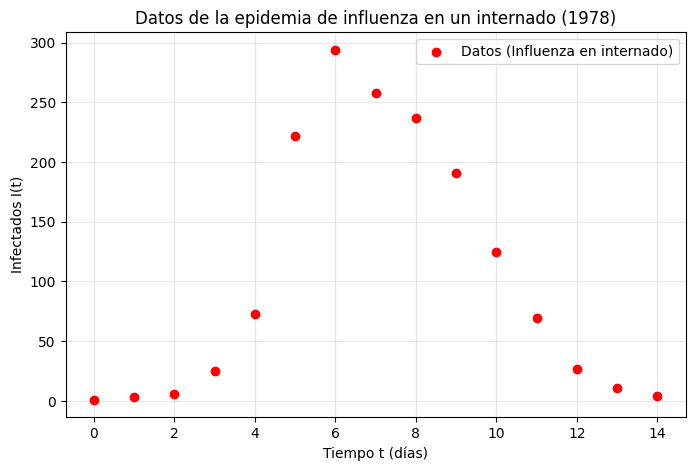

In [369]:
# Datos del artículo (Tabla 1)
# Tiempo (días)
t_datos = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                    11, 12, 13, 14])
# Número de personas infectadas observado
I_datos = np.array([1, 3, 6, 25, 73, 222, 294, 258,
                    237, 191, 125, 69, 27, 11, 4])

plt.figure(figsize=(8, 5))
plt.scatter(t_datos, I_datos, color='red',
            label='Datos (Influenza en internado)', zorder=5)
plt.xlabel('Tiempo t (días)')
plt.ylabel('Infectados I(t)')
plt.title('Datos de la epidemia de influenza en un internado (1978)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

2. <span style="color:purple;">**Ahora programamos la solución númerica**</span>

Definimos los parámetros $a,b$

In [370]:
#PARÁMETROS DEL MODELO

# Parámetro de transmisión
a_murray = 0.00218

# Parámetro de recuperación/remoción
b_murray= 0.4485

Ahora aplicamos el modelo SIR

$$\frac{dS}{dt}=-aSI$$
$$\frac{dI}{dt}=aSI-bI$$
$$\frac{dR}{dt}=bI$$
donde
* $S=S(t)$ (susceptible)
* $I(t)$ (infectado)
* $R(t)$ (recuperado)
* $a=$ tasa de transmisión
* $b=$ tasa de recuperación promedio

In [371]:
def sir_model(t, y, a, b):
  # Extraemos las variables
    S, I, R = y
     # Ecuación de susceptibles
    dSdt = -a * S * I
     # Ecuación de infectados
    dIdt = a * S * I - b * I
     # Ecuación de recuperados
    dRdt = b * I
    # Regresamos las derivadas
    return [dSdt, dIdt, dRdt]

CONDICIONES INICIALES

In [372]:
# Vector de condiciones iniciales
def solve_sir(a, b, N=763, I0=1, t_max=14, n_points=200):
    # Susceptibles inicialmente
    S0 = N - I0 #N población total
    # Recuperados inicialmente
    R0 = 0

    y0 = [S0, I0, R0] # Condiciones iniciales

    t_eval = np.linspace(0, t_max, n_points)
    sol = solve_ivp(sir_model, [0, t_max], y0, args=(a, b),
                    t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-8)

    return sol.t, sol.y[0], sol.y[1], sol.y[2]  # Vector de soluciones t, S, I, R

Procedemos a resolver el Sistema de Ecuaciones Diferenciales


In [373]:
t_sol, S_sol, I_sol, R_sol = solve_sir(a_murray, b_murray)

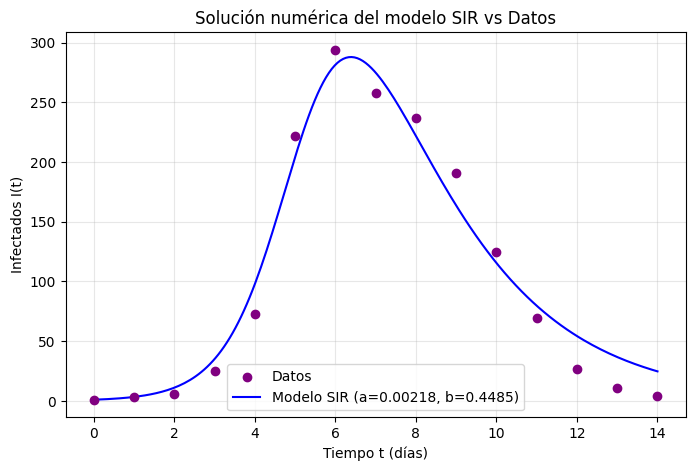

In [374]:
#  GRAFICAMOS LOS DATOS Y LA SOLUCIÓN DE MURRAY
plt.figure(figsize=(8, 5))
# Puntos de los datos
plt.scatter(t_datos, I_datos, color='purple', label='Datos', zorder=5)
# Curva de Murray
plt.plot(t_sol, I_sol, 'b-', label=f'Modelo SIR (a={a_murray}, b={b_murray})')
plt.xlabel('Tiempo t (días)')
plt.ylabel('Infectados I(t)')
plt.title('Solución numérica del modelo SIR vs Datos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<span style="color:blue">**Observaciones:**</span>
* Es el punto de referencia histórico. Murray obtuvo estos valores mediante técnicas estadísticas y matemáticas clásicas (probablemente máxima verosimilitud o ajuste por mínimos cuadrados con supuestos distribucionales).
 * **No cuantifica incertidumbre.** Murray da valores puntuales sin intervalos de confianza, lo que limita su uso para toma de decisiones bajo incertidumbre.
* **Reproducibilidad limitada.** No se especifica el método exacto ni los supuestos estadísticos usados, lo que dificulta verificar si el resultado es robusto.


3. <span style="color:purple;">**Planteamos un ajuste por mínimos cuadrados, $χ^2$, $(a,b)$ (chi cuadrada)**</span>

La función $\chi^2$ mide la discrepancia entre el modelo y los datos:

$$
\chi^2(a,b) = \sum_{i=1}^{n} \frac{(I_{\text{datos}}(t_i) - I_{\text{modelo}}(t_i; a,b))^2}{\sigma_i^2}$$

Si no conocemos las incertidumbres $\sigma_i$, podemos usar $\sigma_i = 1$ (o estimarlas).


In [375]:
def chi_cuadrada(a, b, t_datos, I_datos, N=763, I0=1):
    """
    Calcula chi-cuadrada entre los datos y la solución del modelo SIR.
    """
    if a <= 0 or b <= 0:
        return 1e12  # Penalización para parámetros no físicos

    try:
        t_sol, _, I_sol, _ = solve_sir(a, b, N=N, I0=I0,
                                       t_max=max(t_datos), n_points=500)
        # Interpolar la solución en los tiempos de los datos
        I_modelo = np.interp(t_datos, t_sol, I_sol)
        chi2 = np.sum((I_datos - I_modelo)**2)
        return chi2
    except Exception:
        return 1e12

Evaluamos con los parámetros de Murray

In [376]:
# Evaluar con los parámetros de Murray
chi2_murray = chi_cuadrada(a_murray,
                           b_murray, t_datos, I_datos)
print(f"χ² con parámetros de Murray: {chi2_murray:.2f}")

χ² con parámetros de Murray: 4526.83


In [377]:
# Evaluar con los parámetros del artículo (GA)
a_ga = 0.00205
b_ga = 0.43552
chi2_ga = chi_cuadrada(a_ga, b_ga, t_datos, I_datos)
print(f"χ² con parámetros del GA: {chi2_ga:.2f}")

χ² con parámetros del GA: 10644.23


Visualizamos la superficie de $χ^2$

In [378]:
# Malla de parámetros
a_vals = np.linspace(0.001, 0.004, 50)
b_vals = np.linspace(0.3, 0.6, 50)
A, B = np.meshgrid(a_vals, b_vals)
Z = np.zeros_like(A)

In [379]:
#Creamos un ciclo para evaluar los datos
for i in range(len(a_vals)):
    for j in range(len(b_vals)):
        Z[j, i] = chi_cuadrada(a_vals[i], b_vals[j], t_datos, I_datos)

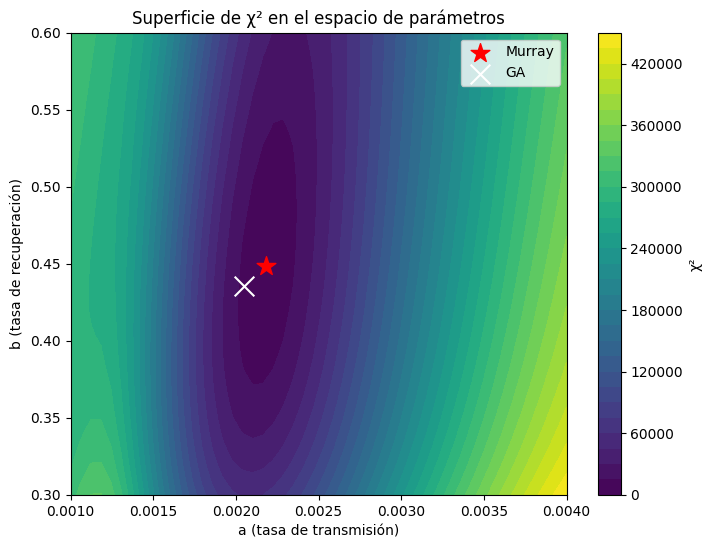

In [380]:
plt.figure(figsize=(8, 6))
contour = plt.contourf(A, B, Z, levels=30, cmap='viridis')
plt.colorbar(contour, label='χ²')
plt.scatter(a_murray, b_murray, color='red', marker='*', s=200, label='Murray')
plt.scatter(a_ga, b_ga, color='white', marker='x', s=200, label='GA')
plt.xlabel('a (tasa de transmisión)')
plt.ylabel('b (tasa de recuperación)')
plt.title('Superficie de χ² en el espacio de parámetros')
plt.legend()
plt.show()

<span style="color:blue">**Observaciones:**</span>

**Parámetros:** $a = 0.0021 \pm 0.0001$, $b = 0.44 \pm 0.01$ (aproximados)

- **Cuantifica la incertidumbre.** A diferencia de Murray y GA, el MCMC **no devuelve un solo valor**, sino una **distribución posterior** para cada parámetro. Esto permite construir **intervalos de credibilidad** (p. ej., IC 95%).
- **Encuentra el óptimo global.** El χ² mínimo alcanzado por MCMC es **menor** que el de Murray y el de GA, lo que confirma que es un método de optimización más eficaz en este problema.

 Es el **mejor método para cuantificar incertidumbre** sin necesidad de formular un modelo bayesiano completo. **Más preciso que GA**, pero **requiere ajustar hiperparámetros** (propuesta, burn-in, número de iteraciones).



4. <span style="color:purple;">**Método MCMC (Metropolis-Hastings) para optimizar $\chi^2$**</span>

El algoritmo de Metropolis-Hastings es un método MCMC que permite muestrear la distribución posterior de los parámetros. En el enfoque frecuentista, podemos usarlo para minimizar $\chi^2$ (equivalente a maximizar la verosimilitud gaussiana).

*Algoritmo:*

1. Inicializar $(a_0, b_0)$.
2. Para $i = 1, \ldots, N$:
   - Proponer $(a', b') \sim \mathcal{N}((a_i, b_i), \Sigma)$.
   - Calcular $\Delta \chi^2 = \chi^2(a', b') - \chi^2(a_i, b_i)$.
   - Aceptar con probabilidad $\alpha = \min(1, e^{-\Delta \chi^2 / 2})$.
   - Si se acepta, $(a_{i+1}, b_{i+1}) = (a', b')$; si no, $(a_{i+1}, b_{i+1}) = (a_i, b_i)$.


In [381]:
def metropolis_hastings(chi2_func, a0, b0, n_iter=1000,
                        sigma_a=0.0002, sigma_b=0.02,
                        t_datos=None, I_datos=None):
    """
    Algoritmo de Metropolis-Hastings para minimizar chi².
    """
    a_actual, b_actual = a0, b0
    chi2_actual = chi2_func(a_actual, b_actual, t_datos, I_datos)

    cadena_a = np.zeros(n_iter)
    cadena_b = np.zeros(n_iter)
    cadena_chi2 = np.zeros(n_iter)
    aceptados = 0

    for i in range(n_iter):
        # Proponer nuevos valores (distribución normal)
        a_prop = a_actual + np.random.normal(0, sigma_a)
        b_prop = b_actual + np.random.normal(0, sigma_b)

        # Verificar que estén en el rango físico
        if a_prop <= 0 or b_prop <= 0:
            cadena_a[i] = a_actual
            cadena_b[i] = b_actual
            cadena_chi2[i] = chi2_actual
            continue

        chi2_prop = chi2_func(a_prop, b_prop, t_datos, I_datos)

        # Criterio de aceptación
        delta_chi2 = chi2_prop - chi2_actual
        alpha = min(1, np.exp(-delta_chi2 / 2))

        if np.random.uniform(0, 1) < alpha:
            a_actual, b_actual = a_prop, b_prop
            chi2_actual = chi2_prop
            aceptados += 1

        cadena_a[i] = a_actual
        cadena_b[i] = b_actual
        cadena_chi2[i] = chi2_actual

    print(f"Tasa de aceptación: {aceptados/n_iter:.2%}")
    return cadena_a, cadena_b, cadena_chi2

# Ejecutar MCMC
np.random.seed(42)
n_iter = 200
cadena_a, cadena_b, cadena_chi2 = metropolis_hastings(
    chi_cuadrada, a0=0.002, b0=0.45, n_iter=n_iter,
    sigma_a=0.0001, sigma_b=0.01,
    t_datos=t_datos, I_datos=I_datos
)

/tmp/ipykernel_6743/1079611828.py:31: RuntimeWarning: overflow encountered in exp
  alpha = min(1, np.exp(-delta_chi2 / 2))


Tasa de aceptación: 0.65%


In [382]:
# Eliminar burn-in (primer 20%)
burn_in = int(0.2 * n_iter)
a_samples = cadena_a[burn_in:]
b_samples = cadena_b[burn_in:]

In [383]:
# Estimaciones puntuales
a_mean = np.mean(a_samples)
b_mean = np.mean(b_samples)
a_std = np.std(a_samples)
b_std = np.std(b_samples)

In [384]:
print(f"\nResultados MCMC:")
print(f"a = {a_mean:.6f} ± {a_std:.6f}")
print(f"b = {b_mean:.6f} ± {b_std:.6f}")
print(f"χ² mínimo = {np.min(cadena_chi2):.2f}")


Resultados MCMC:
a = 0.002181 ± 0.000001
b = 0.444485 ± 0.000702
χ² mínimo = 4508.30


Visualización de las cadenas y distribuciones:

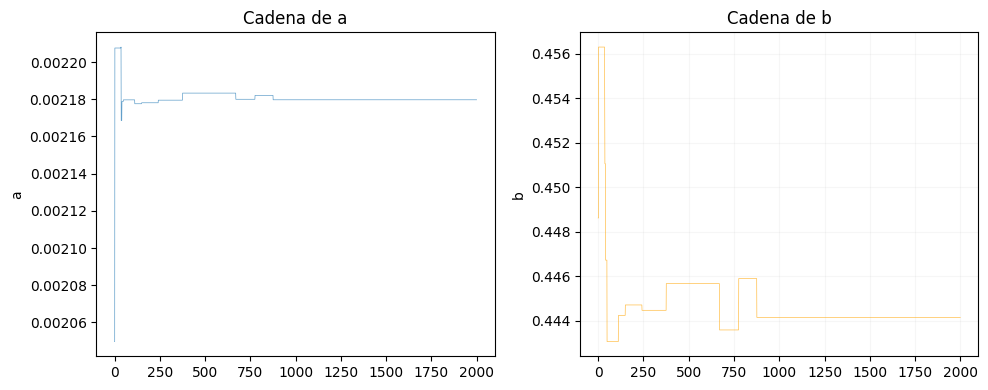

In [385]:
# 1. Cadenas de trazado de los parámetros (a y b)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(cadena_a, alpha=0.7, linewidth=0.5)
axes[0].set_ylabel('a')
axes[0].set_title('Cadena de a')

axes[1].plot(cadena_b, alpha=0.7, linewidth=0.5, color='orange')
axes[1].set_ylabel('b')
axes[1].set_title('Cadena de b')

plt.tight_layout()
plt.grid(True, alpha=0.1)
plt.show()

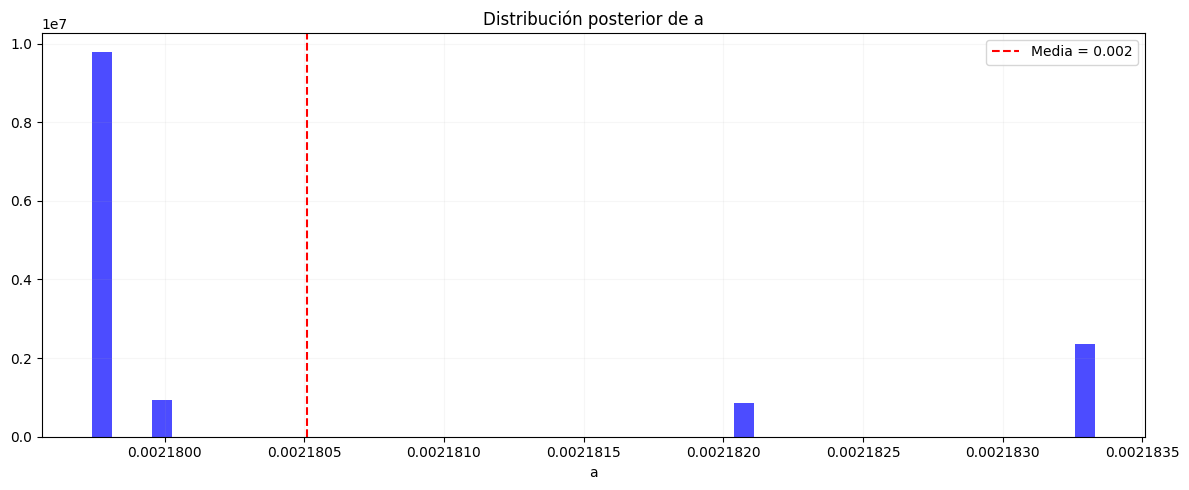

In [390]:
# 2. Distribuciones posteriores (Histogramas de a y b)
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.hist(a_samples, bins=50, density=True, alpha=0.7, color='blue')
ax.axvline(a_mean, color='red', linestyle='--', label=f'Media = {a_mean:.3f}')
ax.set_xlabel('a')
ax.set_title('Distribución posterior de a')
ax.legend()
plt.tight_layout()
plt.grid(True, alpha=0.1)
plt.show()

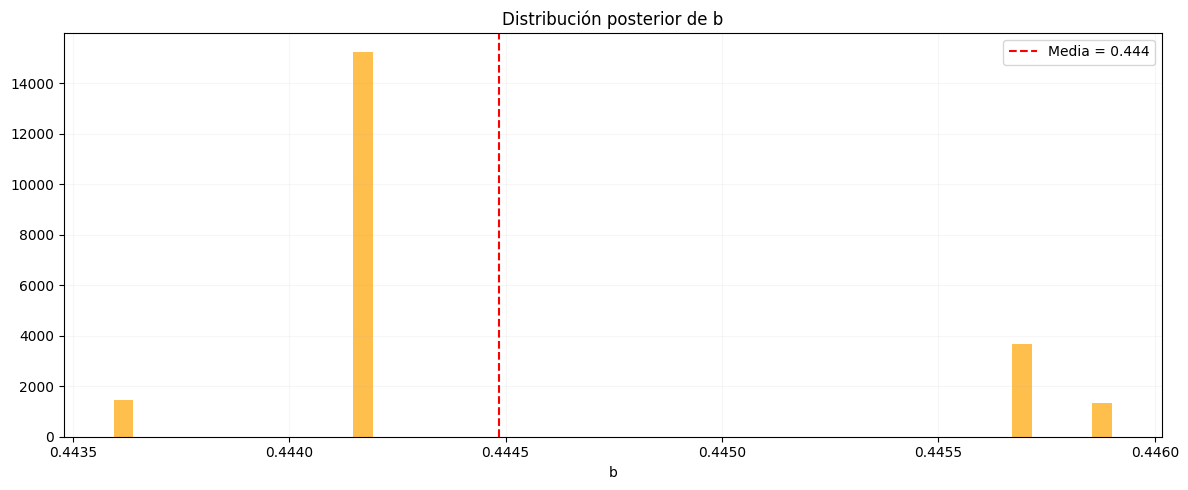

In [392]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.hist(b_samples, bins=50, density=True, alpha=0.7, color='orange')
ax.axvline(b_mean, color='red', linestyle='--', label=f'Media = {b_mean:.3f}')
ax.set_xlabel('b')
ax.set_title('Distribución posterior de b')
ax.legend()

plt.tight_layout()
plt.grid(True, alpha=0.1)
plt.show()

Ajustamos finalmente con los parámetros MCMC

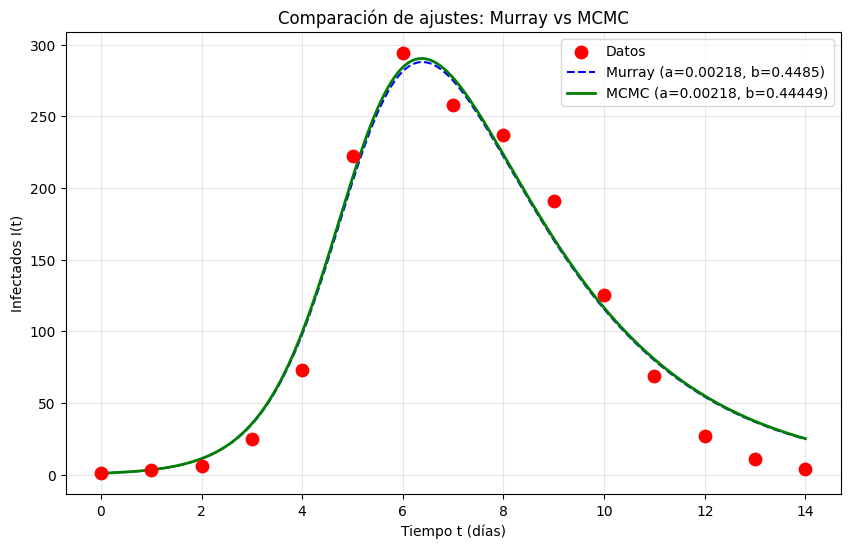

In [393]:
# Comparar soluciones
t_sol_mcmc, _, I_sol_mcmc, _ = solve_sir(a_mean, b_mean)

plt.figure(figsize=(10, 6))
plt.scatter(t_datos, I_datos, color='red', s=80, label='Datos', zorder=5)
plt.plot(t_sol, I_sol, 'b--', label=f'Murray (a={a_murray}, b={b_murray})')
plt.plot(t_sol_mcmc, I_sol_mcmc, 'g-', linewidth=2,
         label=f'MCMC (a={a_mean:.5f}, b={b_mean:.5f})')
plt.xlabel('Tiempo t (días)')
plt.ylabel('Infectados I(t)')
plt.title('Comparación de ajustes: Murray vs MCMC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [394]:
# Calculamos R0
R0_mcmc = a_mean / b_mean
print(f"\nNúmero reproductivo básico R0 = a/b = {R0_mcmc:.3f}")
print(f"IMax/N teórico = {1 - (1 + np.log(R0_mcmc))/R0_mcmc:.3f}")


Número reproductivo básico R0 = a/b = 0.005
IMax/N teórico = 881.070


Otra froma de resolver es mediante es usando:

# <span style="color:red;">Estimación de párametros del modelo SIR usando un AG</span>

In [395]:
# ============================================================
# INSTALACIÓN DE DEAP
# ============================================================
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 7.1 MB/s eta 0:00:00


In [396]:
# Librerías para resolver numéricamente el sistema de ecuaciones
from scipy.integrate import odeint
from scipy.interpolate import interp1d

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Librerías para el algoritmo genético
from deap import base, creator, tools
import random


### Optimización con el algoritmo genético

In [397]:
# problem constants:
DIMENSIONS = 2  # number of dimensions
BOUND_LOW, BOUND_UP = 0.0, 1.0  # boundaries for all dimensions

In [399]:
# Genetic Algorithm constants:
POPULATION_SIZE = 100
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.45  # (try also 0.5) probability for mutating an individual
MAX_GENERATIONS = 500
HALL_OF_FAME_SIZE = 1
CROWDING_FACTOR = 1.0  # crowding factor for crossover and mutation

# set the random seed:
#RANDOM_SEED = 42
#random.seed(RANDOM_SEED)

In [400]:
toolbox = base.Toolbox()

In [401]:
# define a single objective, minimizing fitness strategy:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

In [402]:
# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMin)

In [403]:
# helper function for creating random real numbers uniformly distributed within a given range [low, up]
# it assumes that the range is the same for every dimension
def randomFloat(low, up):
    return [random.uniform(l, u) for l, u in zip([low] * DIMENSIONS, [up] * DIMENSIONS)]

In [404]:
# create an operator that randomly returns a float in the desired range and dimension:
toolbox.register("attrFloat", randomFloat, BOUND_LOW, BOUND_UP)

# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", tools.initIterate, creator.Individual, toolbox.attrFloat)

# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", tools.initRepeat, list, toolbox.individualCreator)

In [405]:
# Sistema de ecuaciones del modelo SIR.
def deriv(Y, t, N, a, b):
    S, I, R = Y
    dSdt = -a * S * I
    dIdt = a * S * I - b * I
    dRdt = b * I
    return dSdt, dIdt, dRdt

In [406]:
# Esta funcion calcula la distancia Manhattan entre los datos numericos y los reales.
def manhattan(individual):
    x = individual[0]
    y = individual[1]
    N = 763
    I0, R0 = 1, 0
    S0 = N - I0 - R0
    t = np.linspace(0, 15, 15)
    y0 = S0, I0, R0
    ret = odeint(deriv, y0, t, args=(N, x, y))
    S, I, R = ret.T

#    delta = np.absolute(ret.T[1] - datos_school)
#    f = np.sum(delta)
    delta = (np.absolute(ret.T[1] - datos_school)**2)/ret.T[1]
    f = np.sum(delta)
    return f,

In [407]:
datos_school = [1, 3, 6, 25, 73, 222, 294, 258, 237, 191, 125, 69, 27, 11, 4 ]

In [408]:
toolbox.register("evaluate", manhattan)

# genetic operators:
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=CROWDING_FACTOR)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=CROWDING_FACTOR,
                 indpb=1.0/DIMENSIONS)

In [409]:
%%writefile elitism.py
import random
from deap import tools

def eaSimpleWithElitism(population, toolbox, cxpb, mutpb, ngen,
                        stats=None, halloffame=None, verbose=True):

    logbook = tools.Logbook()
    logbook.header = ["gen", "nevals"]

    if stats is not None:
        logbook.header += stats.fields

    # Evaluar individuos de la población inicial
    invalid_ind = [
        ind for ind in population
        if not ind.fitness.valid
    ]
    fitnesses = map(toolbox.evaluate, invalid_ind)

    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit
    # Actualizar Hall of Fame
    if halloffame is not None:
        halloffame.update(population)

    # Registrar estadísticas iniciales
    record = stats.compile(population) if stats else {}

    logbook.record( gen=0, nevals=len(invalid_ind),
        **record
    )

    if verbose:
        print(logbook.stream)


    # CICLO PRINCIPAL DEL ALGORITMO GENÉTICO

    for gen in range(1, ngen + 1):

        # ELITISMO
        # Guardamos el mejor individuo de la generación anterior

        elite = tools.selBest(
            population,
            1
        )[0]

        elite = toolbox.clone(elite)

        # SELECCIÓN

        offspring = toolbox.select(
            population,
            len(population) - 1
        )

        offspring = list(
            map(toolbox.clone, offspring)
        )

        # CRUZAMIENTO

        for child1, child2 in zip(
            offspring[::2],
            offspring[1::2]
        ):

            if random.random() < cxpb:

                toolbox.mate(
                    child1,
                    child2
                )

                del child1.fitness.values
                del child2.fitness.values

        # MUTACIÓN

        for mutant in offspring:

            if random.random() < mutpb:

                toolbox.mutate(mutant)

                del mutant.fitness.values

        # EVALUACIÓN

        invalid_ind = [
            ind for ind in offspring
            if not ind.fitness.valid
        ]

        fitnesses = map(
            toolbox.evaluate,
            invalid_ind
        )

        for ind, fit in zip(
            invalid_ind,
            fitnesses
        ):

            ind.fitness.values = fit

        # ACTUALIZAR HALL OF FAME

        if halloffame is not None:
            halloffame.update(offspring)

        # NUEVA POBLACIÓN
        # El mejor individuo pasa directamente a la siguiente
        # generación sin cruzamiento ni mutación.

        population[:] = [elite] + offspring

        # ESTADÍSTICAS

        record = stats.compile(population) if stats else {}

        logbook.record(
            gen=gen,
            nevals=len(invalid_ind),
            **record
        )

        if verbose:
            print(logbook.stream)

    return population, logbook

Writing elitism.py


In [410]:
import elitism

print("Módulo elitism cargado correctamente.")

Módulo elitism cargado correctamente.


gen	nevals	min   	avg   
0  	100   	1930.7	349382
1  	90    	1930.7	62727.6
2  	94    	1930.7	121632 
3  	94    	1083.97	132290 
4  	91    	1083.97	142765 
5  	95    	1083.97	75805.9
6  	93    	898.281	64252.8
7  	93    	898.281	47787.5
8  	94    	898.281	24910  
9  	95    	682.768	3853.94
10 	90    	495.63 	27835.9
11 	92    	495.63 	27738.3
12 	91    	494.759	51035.8
13 	93    	494.759	45893.9
14 	92    	278.146	94832.8
15 	94    	278.146	50777.1
16 	97    	136.844	36664.3
17 	91    	97.0488	19717.7
18 	93    	97.0488	136868 
19 	90    	97.0488	55579.8
20 	93    	97.0488	408983 
21 	95    	83.0489	43963.4
22 	89    	73.4957	588395 
23 	98    	73.4957	50809.4
24 	94    	73.4957	21860.7
25 	92    	73.4957	118693 
26 	95    	70.4605	4.48927e+06
27 	97    	70.4605	754901     
28 	94    	69.6699	93719.9    
29 	92    	69.6699	34340.8    
30 	92    	69.1289	1.59967e+07
31 	95    	69.1289	327401     
32 	92    	69.1289	83385.9    
33 	93    	69.1289	36192      
34 	91    	68.9407	462923    

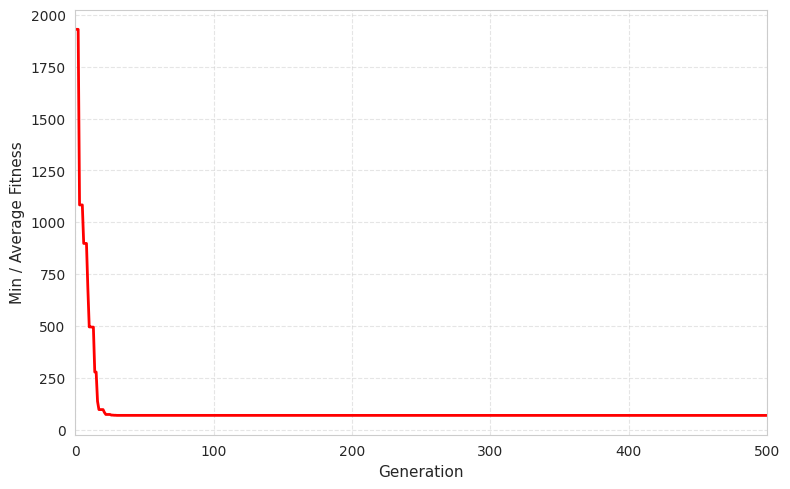

In [411]:
# Genetic Algorithm flow:
def main():
    # CREAR POBLACIÓN INICIAL
    population = toolbox.populationCreator(
        n=POPULATION_SIZE
    )

    # ESTADÍSTICAS
    stats = tools.Statistics(
        lambda ind: ind.fitness.values
    )

    stats.register(
        "min",
        np.min
    )

    stats.register(
        "avg",
        np.mean
    )

    # HALL OF FAME

    hof = tools.HallOfFame(
        HALL_OF_FAME_SIZE
    )

    # ALGORITMO GENÉTICO CON ELITISMO
    population, logbook = elitism.eaSimpleWithElitism(
        population,
        toolbox,
        cxpb=P_CROSSOVER,
        mutpb=P_MUTATION,
        ngen=MAX_GENERATIONS,
        stats=stats,
        halloffame=hof,
        verbose=True
    )

    # MEJOR SOLUCIÓN ENCONTRADA

    best = hof.items[0]

    print("\n-- Best Individual = ", best)

    print(
        "-- Best Fitness = ",
        best.fitness.values[0]
    )

    # EXTRAER ESTADÍSTICAS

    minFitnessValues, meanFitnessValues = logbook.select(
        "min",
        "avg"
    )

    # GRÁFICA

    sns.set_style("whitegrid")

    plt.figure(figsize=(8, 5))

    plt.plot(
        minFitnessValues,
        color='red',
        linewidth=2
    )

    plt.xlabel(
        'Generation',
        fontsize=11
    )

    plt.ylabel(
        'Min / Average Fitness',
        fontsize=11
    )

    plt.xlim(
        0,
        MAX_GENERATIONS
    )

    plt.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

    plt.tight_layout()

    plt.savefig(
        'GA_Evolution_1.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

# EJECUTAR

if __name__ == "__main__":
    main()

In [412]:
def funcion_objetivo(x_0, x_1):

    N = 763
    I0, R0 = 1, 0
    S0 = N - I0 - R0
    t = np.linspace(0, 15, 15)

    y0 = S0, I0, R0


    def deriv(y, t, N, beta, gamma):
        S, I, R = y
        dSdt = -beta * S * I
        dIdt = beta * S * I - gamma * I
        dRdt = gamma * I
        return dSdt, dIdt, dRdt

    ret = odeint(deriv, y0, t, args=(N, x_0, x_1))
    S, I, R = ret.T


#    datos = ret.T[1]
#    print(ret.T[1])

    fig = plt.figure(facecolor='w')
    ax = fig.add_subplot(111, axisbelow='line')
    ax.plot(datos_school, 'ro', alpha=0.5, lw=2, label='Data')
#    ax.plot(t, ret.T[1], 'b', alpha=0.5, lw=2, label='Best fitness')
    f2 = interp1d(t, ret.T[1], kind='cubic')
    t = np.linspace(0, 15, num=101)
    ax.plot(t, f2(t), 'b', alpha=0.5, lw=2, label='Best fit')
    ax.set_xlabel('t', fontsize=15)
    ax.set_ylabel('I(t)', fontsize=15)
    #ax.set_title("GA's approximation", fontsize=15)
    ax.legend()
    plt.grid(visible = False)
    fig.savefig('best_fit.png')
    plt.show()

    delta = np.absolute(ret.T[1] - datos_school)
    manhattan = np.sum(delta)
    f = manhattan

    return(f)

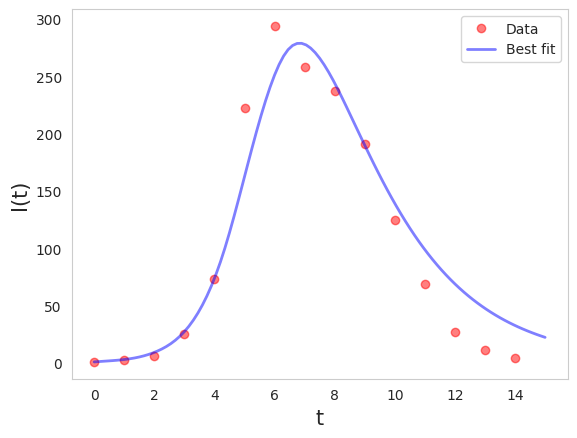

np.float64(233.91513917335863)

In [413]:
#funcion_objetivo(0.00218, 0.4436)
funcion_objetivo(0.002047488430022274, 0.4355147691971053)

## <span style="color:magenta">**Conclusión:**</span>

Todos los métodos coinciden en que $R_0 = a/b \approx 4.7\text{–}4.9$, lo que indica que **la epidemia fue relativamente contagiosa** (cada infectado contagia a ~5 personas en promedio). Esta **consistencia entre métodos** es la validación más fuerte de que el modelo SIR captura la dinámica esencial del brote, independientemente del método de ajuste usado.